### **Load Dataset**

In [13]:
import pandas as pd

train_df = pd.read_csv("train.csv")
train_df.head()


,Image_id,Label
0,id_02amazy34fgh2.jpg,1
1,id_02mh3w48pmyc9.jpg,0
2,id_02rpb463h9d3w.jpg,0
3,id_02wc3jeeao8ol.jpg,1
4,id_03t2hapb8wz8p.jpg,1


### **Basic Understanding**

In [14]:
train_df.info()
train_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1619 entries, 0 to 1618
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Image_id  1619 non-null   object
 1   Label     1619 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 25.4+ KB


,Label
count,1619.000000
mean,0.499691
std,0.500154
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


### **Check Missing & Duplicate Records**

In [15]:
print("Missing Values:\n", train_df.isnull().sum())
print("\nDuplicates:", train_df.duplicated().sum())


Missing Values:
 Image_id    0
Label       0
dtype: int64

Duplicates: 0


In [16]:
train_df["Label"].value_counts()


Label
0    810
1    809
Name: count, dtype: int64

### **Visualizing Whether the dataset is balanced or not**

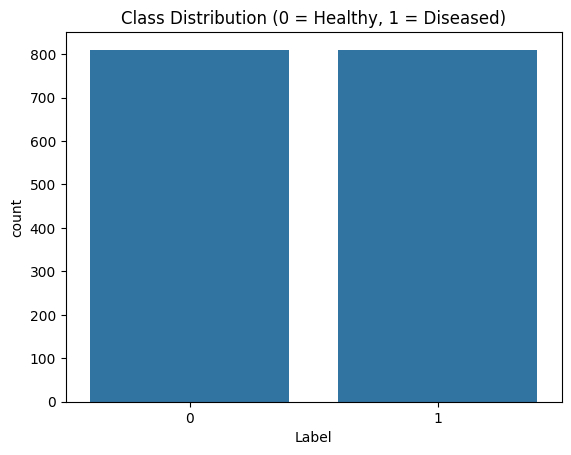

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=train_df["Label"])
plt.title("Class Distribution (0 = Healthy, 1 = Diseased)")
plt.show()


### **Verify Images Exist**

In [18]:
import os

image_dir = "Images"
missing_files = []

for img in train_df["Image_id"]:
    if not os.path.exists(os.path.join(image_dir, img)):
        missing_files.append(img)

print("Missing Images:", len(missing_files))
missing_files[:5]


Missing Images: 0


[]

### **Check Image Shape & Size Consistency**

In [19]:
import cv2

sample = train_df["Image_id"].iloc[0]
path = os.path.join(image_dir, sample)

img = cv2.imread(path)
print("Image Shape:", img.shape)


Image Shape: (1024, 765, 3)


### **Show Sample Images**

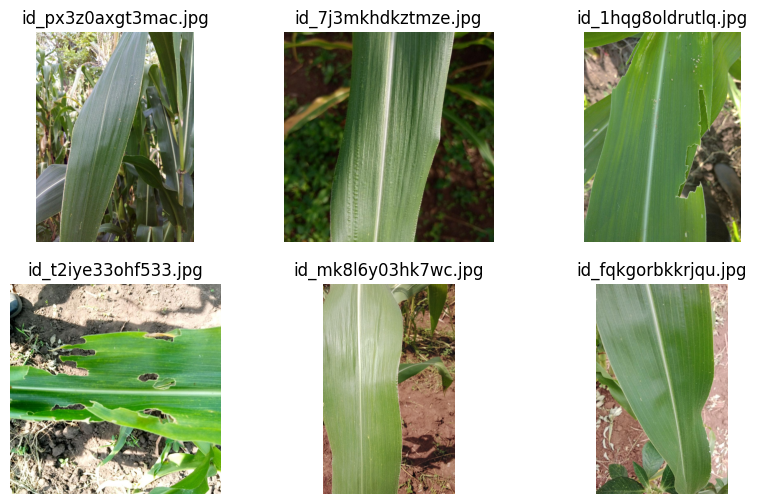

In [20]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10,6))
for i in range(6):
    random_img = random.choice(train_df["Image_id"].values)
    img = cv2.imread(os.path.join(image_dir, random_img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(random_img)

plt.show()


### **Import Required Libraries**

In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


### **Create Train / Validation Split**

In [22]:
from sklearn.model_selection import train_test_split

train_df_split, val_df_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Label"],
    random_state=42
)

len(train_df_split), len(val_df_split)


(1295, 324)

### **Setup Image Generators**

In [23]:
IMG_SIZE = 224
BATCH_SIZE = 32
image_dir = "Images"

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.1
)

val_datagen = ImageDataGenerator(rescale = 1./255)


### **Create Data Pipeline**

In [24]:
train_df_split["Label"] = train_df_split["Label"].astype(str)
val_df_split["Label"] = val_df_split["Label"].astype(str)


In [25]:
train_gen = train_datagen.flow_from_dataframe(
    train_df_split,
    directory=image_dir,
    x_col="Image_id",
    y_col="Label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df_split,
    directory=image_dir,
    x_col="Image_id",
    y_col="Label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 1295 validated image filenames belonging to 2 classes.
Found 324 validated image filenames belonging to 2 classes.


### **Confirm Class Mapping (VERY IMPORTANT)**

In [26]:
print("Class indices:", train_gen.class_indices)


Class indices: {'0': 0, '1': 1}


### **Build Model 1 (Simple CNN)**

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model1 = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")  # binary classification
])

model1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model1.summary()


C:\Users\HP\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### **Train Model 1**

In [25]:
EPOCHS = 10

history1 = model1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)



Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.5444 - loss: 0.7025 - val_accuracy: 0.6420 - val_loss: 0.6438
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.6826 - loss: 0.6097 - val_accuracy: 0.7500 - val_loss: 0.5326
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7467 - loss: 0.5313 - val_accuracy: 0.7778 - val_loss: 0.4823
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7938 - loss: 0.4653 - val_accuracy: 0.7809 - val_loss: 0.4202
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7992 - loss: 0.4524 - val_accuracy: 0.8179 - val_loss: 0.3993
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.7923 - loss: 0.4474 - val_accuracy: 0.8210 - val_loss: 0.3854
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.8054 - loss: 0.4334 - val_accuracy: 0.8364 - val_loss: 0.3711
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.8208 - loss: 0.4105 - val_accuracy: 0.8241 - val_loss:

### **Plot Training vs Validation Performance**

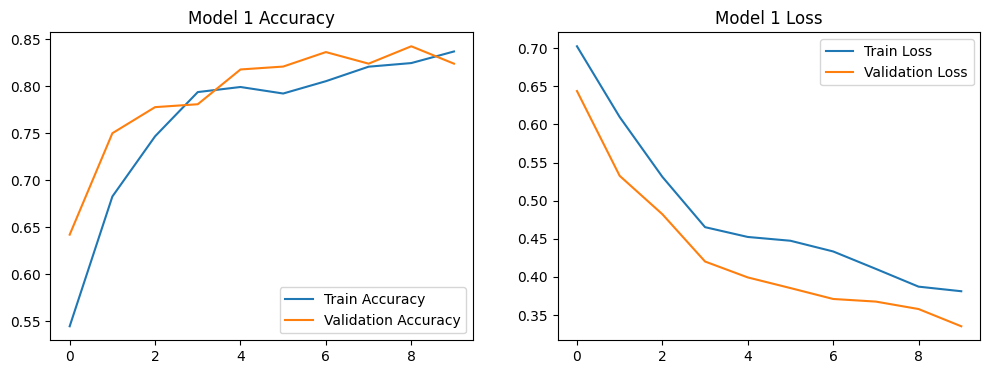

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history1.history["accuracy"], label="Train Accuracy")
plt.plot(history1.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 1 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history1.history["loss"], label="Train Loss")
plt.plot(history1.history["val_loss"], label="Validation Loss")
plt.title("Model 1 Loss")
plt.legend()

plt.show()


### **Final Validation Metrics (Accuracy + ROC-AUC)**

In [27]:
from sklearn.metrics import roc_auc_score
import numpy as np

val_gen.reset()
y_true = val_gen.classes
y_pred_prob = model1.predict(val_gen).ravel()

roc_auc = roc_auc_score(y_true, y_pred_prob)
print("Model 1 Validation ROC-AUC:", roc_auc)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 560ms/step
Model 1 Validation ROC-AUC: 0.9356043286084438


In [28]:
model1.save("model1_simple_cnn.h5")
print("Model saved as model1_simple_cnn.h5")


Model saved as model1_simple_cnn.h5


### **Build Model-2 (Deeper CNN)**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
IMAGE_DIR = "Images"


In [9]:
df = pd.read_csv("train.csv")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Label"],
    random_state=42
)

train_df["Label"] = train_df["Label"].astype(str)
val_df["Label"] = val_df["Label"].astype(str)

train_df.head()


,Image_id,Label
1270,id_sp24ia9u5ihvp.jpg,1
267,id_6196n4jlhpzmb.jpg,1
1280,id_swnxvp6pjavsg.jpg,1
427,id_9u765gje93870.jpg,1
627,id_dw0v152dwaf2k.jpg,1


In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)


In [13]:
model2 = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.5900 - loss: 0.7416 - val_accuracy: 0.6451 - val_loss: 0.6145
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.7097 - loss: 0.5944 - val_accuracy: 0.7593 - val_loss: 0.4884
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7560 - loss: 0.5216 - val_accuracy: 0.7685 - val_loss: 0.5570
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 188s 5s/step - accuracy: 0.7822 - loss: 0.5106 - val_accuracy: 0.8148 - val_loss: 0.4304
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7992 - loss: 0.4651 - val_accuracy: 0.8179 - val_loss: 0.4059
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8332 - loss: 0.3972 - val_accuracy: 0.8241 - val_loss: 0.3683
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8564 - loss: 0.3662 - val_accuracy: 0.8580 - val_loss: 0.3742
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.8834 - loss: 0.2895 - val_accuracy: 0.8704 - val_loss

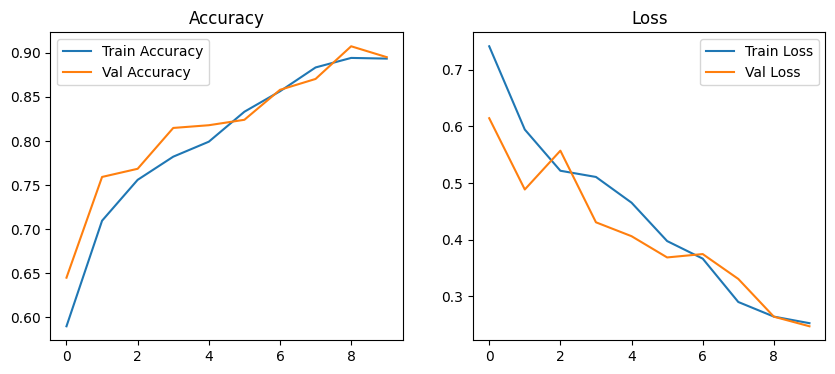

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [16]:
val_loss, val_acc = model2.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 470ms/step - accuracy: 0.8951 - loss: 0.2466
Validation Accuracy: 0.8951


In [17]:
model2.save("model2_cnn.h5")
print("Model saved as model2_cnn.h5")


Model saved as model2_cnn.h5


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


C:\Users\HP\myenv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
IMAGE_DIR = "Images"


In [7]:
df = pd.read_csv("train.csv")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Label"],
    random_state=42
)

train_df["Label"] = train_df["Label"].astype(str)
val_df["Label"] = val_df["Label"].astype(str)


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)


In [9]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    directory=IMAGE_DIR,
    x_col="Image_id",
    y_col="Label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    directory=IMAGE_DIR,
    x_col="Image_id",
    y_col="Label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
CLASS_NAMES


Found 1295 validated image filenames belonging to 2 classes.
Found 324 validated image filenames belonging to 2 classes.


['0', '1']

In [10]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False


In [11]:
model3 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model3.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model3.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model3.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7127 - loss: 0.5526 - val_accuracy: 0.8735 - val_loss: 0.3450
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8803 - loss: 0.3045 - val_accuracy: 0.9228 - val_loss: 0.2457
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9158 - loss: 0.2240 - val_accuracy: 0.9352 - val_loss: 0.1983
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9297 - loss: 0.1919 - val_accuracy: 0.9414 - val_loss: 0.1657
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9367 - loss: 0.1633 - val_accuracy: 0.9568 - val_loss: 0.1499
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9583 - loss: 0.1358 - val_accuracy: 0.9599 - val_loss: 0.1482
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9514 - loss: 0.1337 - val_accuracy: 0.9599 - val_loss: 0.1367
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9583 - loss: 0.1215 - val_accuracy: 0.9568 - val_loss:

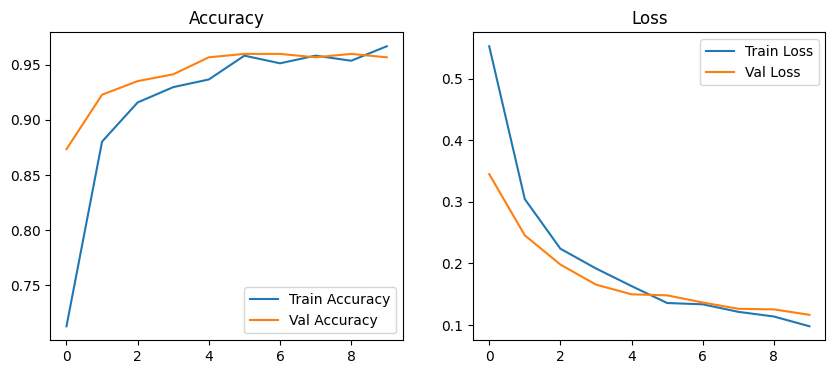

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [14]:
val_loss, val_acc = model3.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 670ms/step - accuracy: 0.9568 - loss: 0.1166
Validation Accuracy: 0.9568


In [15]:
model3.save("model3_mobilenetv2.h5")
print("Model saved as model3_mobilenetv2.h5")


Model saved as model3_mobilenetv2.h5


In [27]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [29]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [30]:
train_gen = train_datagen.flow_from_dataframe(
    train_df_split,
    directory="Images",
    x_col="Image_id",
    y_col="Label",
    target_size=(224, 224),
    class_mode="binary",
    batch_size=32,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df_split,
    directory="Images",
    x_col="Image_id",
    y_col="Label",
    target_size=(224, 224),
    class_mode="binary",
    batch_size=32,
    shuffle=False
)


Found 1295 validated image filenames belonging to 2 classes.
Found 324 validated image filenames belonging to 2 classes.


In [33]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # PHASE 1


In [34]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model4 = Model(inputs=base_model.input, outputs=output)


In [36]:
model4.compile(
    optimizer=Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [37]:
history4_phase1 = model4.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)


Epoch 1/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9012 - loss: 0.2352 - val_accuracy: 0.9599 - val_loss: 0.0863
Epoch 2/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9629 - loss: 0.0974 - val_accuracy: 0.9722 - val_loss: 0.0739
Epoch 3/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9807 - loss: 0.0624 - val_accuracy: 0.9753 - val_loss: 0.0719
Epoch 4/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9745 - loss: 0.0589 - val_accuracy: 0.9753 - val_loss: 0.0611
Epoch 5/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9776 - loss: 0.0616 - val_accuracy: 0.9722 - val_loss: 0.0713


In [38]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False


In [39]:
model4.compile(
    optimizer=Adam(1e-4),  # lower LR
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [40]:
history4_phase2 = model4.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8
)


Epoch 1/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9606 - loss: 0.1196 - val_accuracy: 0.9722 - val_loss: 0.0643
Epoch 2/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9853 - loss: 0.0564 - val_accuracy: 0.9784 - val_loss: 0.0500
Epoch 3/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9853 - loss: 0.0425 - val_accuracy: 0.9815 - val_loss: 0.0396
Epoch 4/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9931 - loss: 0.0225 - val_accuracy: 0.9815 - val_loss: 0.0382
Epoch 5/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9915 - loss: 0.0239 - val_accuracy: 0.9815 - val_loss: 0.0341
Epoch 6/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9907 - loss: 0.0259 - val_accuracy: 0.9877 - val_loss: 0.0244
Epoch 7/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9946 - loss: 0.0171 - val_accuracy: 0.9907 - val_loss: 0.0234
Epoch 8/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9954 - loss: 0.0148 - val_accuracy: 0.9907 - val_loss: 0.0208

In [41]:
val_loss, val_acc = model4.evaluate(val_gen)
print(f"Model 4 Validation Accuracy: {val_acc:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 731ms/step - accuracy: 0.9907 - loss: 0.0208
Model 4 Validation Accuracy: 0.9907


In [42]:
model4.save("model4_efficientnet.h5")


In [53]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10


In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df_split,
    directory="Images",
    x_col="Image_id",
    y_col="Label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df_split,
    directory="Images",
    x_col="Image_id",
    y_col="Label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 1295 validated image filenames belonging to 2 classes.
Found 324 validated image filenames belonging to 2 classes.


In [57]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # transfer learning (stable)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model5 = Model(inputs=base_model.input, outputs=output)

model5.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model5.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_4 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_2               │ (None, 224, 224, 3)       │               7 │ rescaling_4[0][0]          │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_5 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_5[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             28

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [59]:
steps_per_epoch = train_gen.samples // BATCH_SIZE
validation_steps = val_gen.samples // BATCH_SIZE

history = model5.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.8464 - loss: 0.4466 - val_accuracy: 0.8969 - val_loss: 0.4150
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 206ms/step - accuracy: 0.8125 - loss: 0.4549 - val_accuracy: 0.8969 - val_loss: 0.4144
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8646 - loss: 0.4159 - val_accuracy: 0.9062 - val_loss: 0.3906
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step - accuracy: 0.8438 - loss: 0.4530 - val_accuracy: 0.9062 - val_loss: 0.3901
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8781 - loss: 0.4030 - val_accuracy: 0.9156 - val_loss: 0.3690
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 0.9688 - loss: 0.3278 - val_accuracy: 0.9156 - val_loss: 0.3685
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8931 - loss: 0.3821 - val_accuracy: 0.9156 - val_loss: 0.3499
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 0.8750 - loss: 0.3907 - val_accuracy: 0.9156 - v

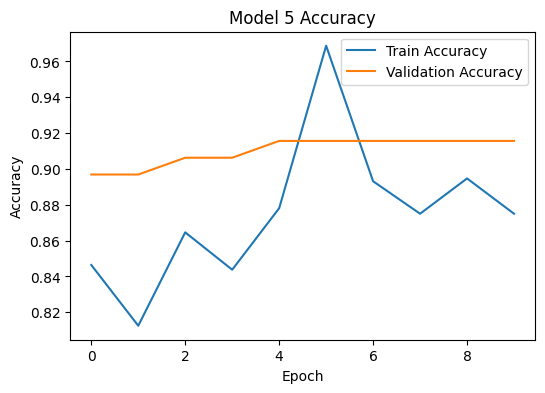

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 5 Accuracy")
plt.legend()
plt.show()


In [61]:
val_loss, val_acc = model5.evaluate(val_gen, steps=validation_steps)
print("Model 5 Validation Accuracy:", round(val_acc, 4))


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 803ms/step - accuracy: 0.9156 - loss: 0.3328
Model 5 Validation Accuracy: 0.9156


In [ ]:
test_steps = test_gen.samples // BATCH_SIZE

test_loss, test_acc = model5.evaluate(test_gen, steps=test_steps)
print("Model 5 Test Accuracy:", round(test_acc, 4))


In [63]:
model5.save("model_5_efficientnetb0_final.h5")
